# Lab 5 Report:
## Create Arthur Conan Doyle AI with RNN

### Nate Chaoweeraprasit

In [360]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.distributions import Categorical

In [361]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [362]:
from IPython.display import Image # For displaying images in colab jupyter cell

## Prepare Data

In [363]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cuda")
print(device)

# You will train on the first N characters of the Sherlock Holmes book
# Pick the size of your training data, i.e. N
data_size_to_train = 8000

# Load the Sherlock Holmes data up to data_size_to_train
data = open('/content/drive/MyDrive/phys 417/lab_05/sherlock.txt', 'r').read()[:data_size_to_train]

# Find the set of unique characters within the training data
characters = sorted(list(set(data)))

# total number of characters in the training data and number of unique characters
data_size, vocab_size = len(data), len(characters)

print("Data has {} characters, {} unique".format(data_size, vocab_size))

cuda
Data has 8000 characters, 65 unique


In [364]:
# Use Python Dictionary to map the characters to numbers and vice versa
# one hot?
char_to_num = { ch:i for i,ch in enumerate(characters) }
num_to_char = { i:ch for i,ch in enumerate(characters) }

In [365]:
# Use the character_to_num dictionary to map each character in the training dataset to a number
data = list(data)

for i, ch in enumerate(data):
    data[i] = char_to_num[ch]

print(data[:10])

[0, 1, 1, 1, 1, 1, 1, 1, 1, 1]


## Define Model

In [366]:
class CharRNN(torch.nn.Module):

    def __init__(self, num_embeddings, embedding_dim, input_size, hidden_size, num_layers, output_size):

        super(CharRNN, self).__init__()

        # Define embedding layer
        # num_embeddings = number of unique characters
        # embedding_dim = size of a vector that encodes each character
        self.embedding = torch.nn.Embedding(num_embeddings, embedding_dim)

        # Define vanilla RNN cell
        # num_layers = Number of RNN cells to be stacked for deep-RNN
        # nonlinearity = Activation function to use
        self.rnn = torch.nn.RNN(input_size=input_size, hidden_size=hidden_size,
                                num_layers=num_layers,
                                nonlinearity = 'relu')

        # decoder layer that takes hidden states as inputs and output probabilities for each character
        # output_size = number of unique characters
        self.decoder = torch.nn.Linear(hidden_size, output_size)

    def forward(self, input_seq, hidden_state):

        # Forward pass input sequence to embedding layer
        embedding = self.embedding(input_seq)

        # RNN cell takes output of embedding layer + previous hidden state as inputs
        output, hidden_state = self.rnn(embedding, hidden_state)

        # Forward pass the RNN cell output to decoder to get the probabilities
        output = self.decoder(output)

        # hidden states need to be detached from computation graph to be re-used as input
        return output, hidden_state.detach()

## Define Hyperparameters

In [367]:
# Fix random seed
torch.manual_seed(25)

# Define RNN network
rnn = CharRNN(num_embeddings = vocab_size,
              embedding_dim = 128,
              input_size = 128,
              hidden_size = 256,
              num_layers = 2,
              output_size=vocab_size)

# Define learning rate and epochs
learning_rate = 0.00073
epochs = 75

# Size of the input sequence to be used during training and validation
training_sequence_len = 30
validation_sequence_len = 250

# Define loss function and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(rnn.parameters(), lr=learning_rate)

# add .cuda() for GPU acceleration
rnn = rnn.to(device)

## Identify Tracked Values

In [368]:
# Tracking training loss per each input/target sequence fwd/bwd pass
training_loss = []

## Train Model

In [369]:
# Convert training data into torch tensor and make it into vertical orientation (N, 1)
# Attach .cuda() if using GPU
data = torch.unsqueeze(torch.tensor(data), dim = 1)
data = data.to(device)

# Training Loop ----------------------------------------------------------------------------------------------------------

for epoch in range(epochs):

    # Randomly select a starting character from first 100 characters in training set
    character_loc = np.random.randint(100)

    # iteration number to keep track of until the sequence reaches the end of training data
    iteration = 0

    # initialize initial hiddens state as None
    hidden_state = None

    # Sample and generate a text sequence after every epoch --------------------------------------------------------------

    while character_loc + training_sequence_len + 1 < data_size: # loop continues until target_seq reaches end of the data

        # Define input/target sequence
        input_seq = data[character_loc : character_loc + training_sequence_len]
        target_seq = data[character_loc + 1 : character_loc + training_sequence_len + 1]

        input_seq = input_seq.to(device)
        target_seq = target_seq.to(device)

        # Pass input sequence and hidden_state to RNN
        output, hidden_state = rnn(input_seq, hidden_state)

        # Compute loss between RNN output sequence vs target sequence
        # torch.squeeze removes the column dimension and make them into horizontal orientation
        loss = loss_fn(torch.squeeze(output), torch.squeeze(target_seq))

        # Append loss
        training_loss.append(loss.item())

        # Empty gradient buffer -> backpropagation -> update network
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Update starting character for next sequence
        character_loc += training_sequence_len

        # Update iteration number
        iteration += 1

    print(f"EPOCH {epoch+1:02d} | AVERAGE TRAINING LOSS: {np.mean(training_loss[-iteration:]):.6f}")

    #Initialize character location and hidden state for validation
    character_loc = 0
    hidden_state = None

    # Pick a random character from the dataset as an initial input to RNN
    rand_index = np.random.randint(data_size-1)
    input_seq = data[rand_index : rand_index+1]


    print("----------------------------------------")

    while character_loc < validation_sequence_len: # Loop continues until RNN generated sequence is in desired length

        # Pass validation sequence to RNN
        # Note that RNN now uses its previous output character as input
        output, hidden_state = rnn(input_seq, hidden_state)

        # Take the softmax of the decoder output to get the probabilities of predicted characters
        output = torch.nn.functional.softmax(torch.squeeze(output), dim=0)
        # Use the  probabilities to sample the output character
        character_distribution = torch.distributions.Categorical(output)
        character_num = character_distribution.sample()

        # Convert the character number selected from sampling to actual character and print
        print(num_to_char[character_num.item()], end='')

        # Update the input_seq so that it's using the output of the RNN as new input
        input_seq[0][0] = character_num.item()

        # Update the character location
        character_loc += 1

    print("\n----------------------------------------\n")

EPOCH 01 | AVERAGE TRAINING LOSS: 2.433864
----------------------------------------
woato
 min
 ,seurosee corkyonge
 costens woban ies
ecp the sees whe Ho liereiss
 sayu los, ke le Hation a




 shreatg wos Bal, as nuk aie ey cothrsestast

In thad hor droth as to long bees i ar we Po I he lhe dytt woshet wonxmstonhh Com oolm mis hy 
----------------------------------------

EPOCH 02 | AVERAGE TRAINING LOSS: 1.972585
----------------------------------------
e buagrey me Esofne. de beriwtly mouwCriottrougstormit. a keepbee, as
 whoth my
 wobshilps
 tho he nerfar.h Lorsi8plouroy,
 ned the hich mimp.
 py. was or ther beressulksfevin it tho as, coljin'  fo wlad traas as lathe that the tavaspany toudscomedip
----------------------------------------

EPOCH 03 | AVERAGE TRAINING LOSS: 1.806953
----------------------------------------
losshoncungulayir, un to misservestor.ing wornepe
     TAgady to fors  CorinlsuxI, as
ed. my forned in the condernowh" The sosmomLing soorn thatl, gostey B
 ku. p

## Visualize & Evaluate Model

ne tapped me on the shoulder, and
 turning round, deisueded to see me. In the exuberance of my joy, I asked in companion; "you are the second
 man to-day that has used that expression to me."

 "And who was the time that we reached our destination.

In [370]:
# Print a validation text sequence that most closely resembles Sherlock Holmes style


In [371]:
# Import seaborn for prettier plot
import seaborn as sns

sns.set(style = 'whitegrid', font_scale = 2.5)

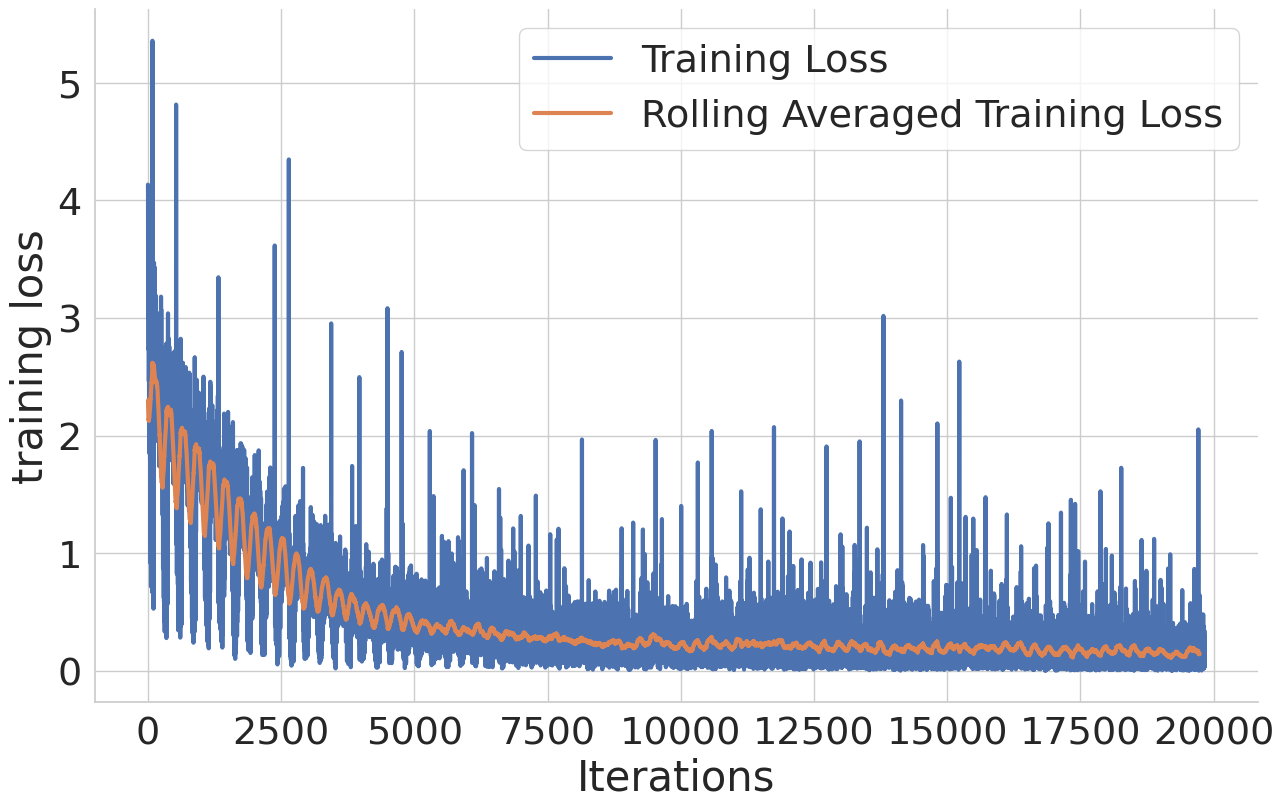

In [372]:
# Plot the training loss and rolling mean training loss with respect to iterations
# Feel free to change the window size
plt.figure(figsize = (15, 9))

plt.plot(training_loss, linewidth = 3, label = 'Training Loss')
plt.plot(np.convolve(training_loss, np.ones(100), 'valid') / 100,
         linewidth = 3, label = 'Rolling Averaged Training Loss')
plt.ylabel("training loss")
plt.xlabel("Iterations")
plt.legend()
sns.despine()